<a href="https://colab.research.google.com/github/VelasquezE/FourierOptics_assignments/blob/main/talleres/Proyecto/inline_hologram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulación holograma en línea**

# 0. Importar librerías necesarias

In [131]:
import numpy as np
from scipy.fft import fft2, fftshift, ifftshift, ifft2, ifftshift
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import seaborn as sns
from scipy.fft import fftfreq

In [132]:
# Estilo por defecto para notebooks
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

# Personalización gráficas

sns.set_style("darkgrid")

custom_rc = {
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.edgecolor": "black",
    "grid.color": "#bbbbbb",
    "grid.linestyle": "dashed",
    "axes.grid": True,
    "axes.spines.top": True,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True
}
sns.set_context("notebook")
sns.set_style("darkgrid", rc = custom_rc)

# 1. Creación del objeto

Se creará un círculo no-absorbente (introduce un cambio de fase pero no atenúa la luz) con fase constante, Para ello, se crea una rejilla llena de unos, con una máscara circular de fase arbitraria.

In [133]:
N = 512 # px
r_circle = 50 # px
phase = 0.75 # radians

center = N / 2
W, H = np.meshgrid(np.arange(0, N), np.arange(0, N))
circle_mask = np.sqrt((W - center) ** 2 + (H - center) ** 2) <= r_circle

object_circle = np.ones((N, N), dtype = np.complex128)
object_circle[circle_mask] = np.exp(1j * phase)

El objeto puede visualizarse,

In [134]:
def plot_complex_visualization(field, log_scale: bool = False):
  fig, (ax1, ax2) = plt.subplots(1, 2)
  if log_scale:
    ax1.imshow(np.log(np.abs(field)), cmap = "viridis")
  else:
    ax1.imshow(np.abs(field), cmap = "viridis")
  ax1.set_title("Amplitud")
  ax1.axis("off")
  ax2.imshow(np.angle(field), vmin = 0, vmax = 2 * np.pi)
  ax2.set_title("Fase")
  ax2.axis("off")

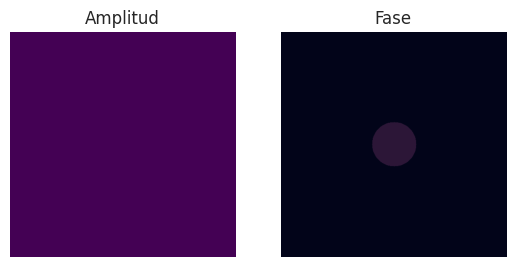

In [135]:
plot_complex_visualization(object_circle)

# 2. Fijar las dimensiones físicas

Se deben fijar las dimensiones físicas del problemas. Es decir, conocer la equivalencia del píxel en milímetros. Se define el sistema de coordenadas del plano espacial,

In [136]:
pixel_size = 0.1 # microns

x = np.linspace(-pixel_size * N / 2, pixel_size * N / 2, num = N, endpoint = True)

Para realizar la transformada de Fourier es necesario definir los arreglos de las frecuencias espaciales. Para ello, se calcula el espacio entre puntos, se calcula la frecuencia espacial de muestreo, se define el tamaño del píxel en el domino de frecuencias, y finalmente se crea el arreglo de frecuencias espaciales permitidas.

In [156]:
dx = np.diff(x)[0]
df = 1 / (N * dx)
f = fftshift(fftfreq(len(x), dx))

# 3. Computar el holograma

Se asume que se ilumina el objeto con una onda plana.

## 3.1. Calcular la transformada de Fourier del objeto

In [139]:
def get_fourier_transform(matrix: np.ndarray, delta_x) -> np.ndarray:
  """
  Calculates the fourier transform and centers it.

  Parameters:
    - matrix (np.ndarray)
  """
  fourier_transform = fftshift(fft2(ifftshift(matrix))) * (delta_x**2)
  return fourier_transform

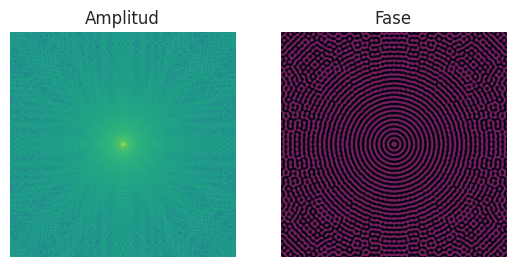

In [140]:
fft_object = get_fourier_transform(object_circle, dx)

plot_complex_visualization(fft_object, log_scale = True)

El resultado puede verificarse:

In [157]:
gt_int = simpson(simpson(np.abs(object_circle)**2, dx=dx), dx=dx)
GT_int = simpson(simpson(np.abs(fft_object)**2, dx=df), dx=df)

print('Integral, object: {:.4f}'.format(gt_int))
print('Integral, Fourier transform of object: {:.4f}'.format(GT_int))

Integral, object: 2621.4400
Integral, Fourier transform of object: 1193.1264


In [158]:
# Compute the average of the original object
gt_avg = np.sum(object_circle) * dx**2 / (x[-1] - x[0])**2
print('Average of the object field: {:.4f}'.format(gt_avg))

Average of the object field: 0.9959+0.0205j


In [159]:
dc_term = fft_object[N // 2, N // 2] * df**2
print('DC term: {:.4f}'.format(dc_term))

DC term: 0.9920+0.0204j


## 3.2. Crear el propagador de espectro angular

Con la transformada de Fourier del objeto se obtuvo el arreglo de ondas planas que viajan formando el objeto. Para conocer el campo en otro plano, se debe hacer avanzar la fase de cada onda plana en una cantidad que depende de la longitud de onda de la luz y del ángulo al que viaja respecto al eje óptico.
Esto se logra multiplicando la transformado de Fourier del objeto con la función de transferencia del espacio libre.

In [173]:
def H(fx, fy, z, wavelength=0.5):
  argument = 1 - (wavelength*fx)**2 - (wavelength*fy)**2
  argument[argument < 0] = 0
  square_root = np.sqrt(argument)
  factor = 1j * 2 * np.pi * z / wavelength
  return np.exp(factor * square_root)

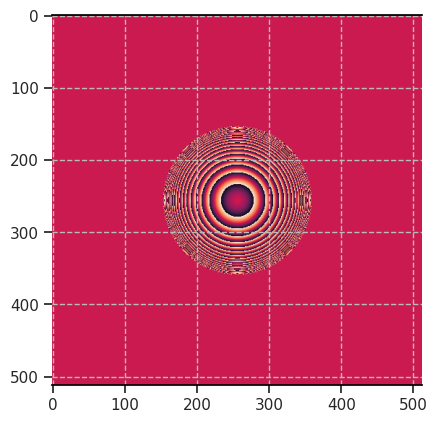

In [174]:
FX, FY = np.meshgrid(f, f)
propagator = H(FX, FY, 10)

fig, ax = plt.subplots(nrows=1, ncols=1)
img = ax.imshow(np.angle(propagator))

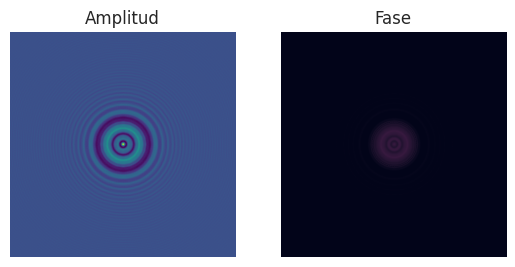

In [176]:
distance = 10 # microns
gt_prime = fftshift(ifft2(ifftshift(fft_object * H(FX, FY, distance)))) / dx**2
plot_complex_visualization(gt_prime)

In [178]:
gt_int       = simpson(simpson(np.abs(object_circle)**2, dx=dx), dx=dx)
GT_int       = simpson(simpson(np.abs(fft_object)**2, dx=df), dx=df)
gt_prime_int = simpson(simpson(np.abs(gt_prime)**2, dx=dx), dx=dx)
print('Integral, object: {:.4f}'.format(gt_int))
print('Integral, Fourier transform of object: {:.4f}'.format(GT_int))
print('Integral, hologram plane: {:.4f}'.format(gt_prime_int))

Integral, object: 2621.4400
Integral, Fourier transform of object: 1193.1264
Integral, hologram plane: 2621.4418
